In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [25]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [130]:

def build_dataset(words):

    block_size = 3

    X,Y = [],[]

    for w in words:

        #print(w)
        context = [0] * block_size

        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [138]:
Xtr.shape, Xtr.dtype, Ytr.shape, Ytr.dtype

(torch.Size([182625, 3]), torch.int64, torch.Size([182625]), torch.int64)

In [171]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [172]:
sum(p.nelement() for p in parameters)

11897

In [173]:
for p in parameters: 
    p.requires_grad = True
    

In [174]:
lre = torch.linspace(-3, 0, 1000)
lrs =10**lre

lri = []
lossi = []
stepi= []


In [183]:
for i in range(50000):
    
    #minibatch construct
    ix = torch.randint(0,Xtr.shape[0], (32,))
    
    emb = C[Xtr[ix]]                                  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)   # (32, 100)
    logits = h @ W2 + b2
    # (32, 27)
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims=True)
    # loss = -prob[torch.arange(32), Y].log().mean()

    loss = F.cross_entropy(logits,Ytr[ix])
    #print(loss.item())
    #backward pass
    
    for p in parameters: 
        p.grad = None
    loss.backward()
    #update
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    #track stats
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
    
print(loss.item())

2.0409181118011475


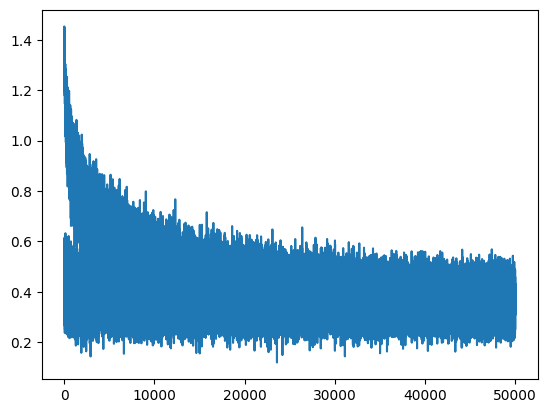

In [184]:
plt.plot(stepi,lossi)

In [185]:
#to show the dependency on characters
#logits.max(1)
emb = C[Xtr]                                # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)   # (32, 100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ytr)
loss

tensor(2.1642, grad_fn=<NllLossBackward0>)

In [186]:
#to show the dependency on characters
#logits.max(1)
emb = C[Xdev]                                # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)   # (32, 100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ydev)
loss

tensor(2.1914, grad_fn=<NllLossBackward0>)

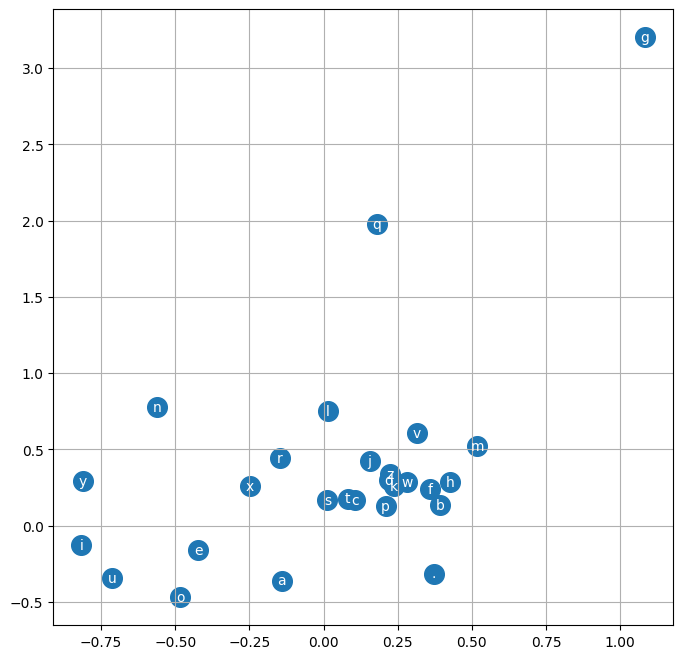

In [162]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [191]:
#sample from the model

g = torch.Generator().manual_seed(37841736472 + 5)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs= F.softmax(logits, dim= 1)
        ix = torch.multinomial(probs, num_samples = 1, generator= g).item()
        context = context[1:] +[ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))
            


rayden.
niode.
yas.
doia.
aetor.
hasiah.
thyana.
savonnethayda.
oliah.
lucetezaniah.
lowrnn.
kyia.
zudin.
len.
kafa.
jael.
ryrah.
bowfaenromahzariya.
kyn.
riah.
